In [1]:
import sys
import rbms

print(sys.executable)
print(rbms.__file__)


/Users/aidan/Documents/Research_Internship/Code/rbms/rbms/dataset/dataset_class.py:10: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


/Users/aidan/Documents/Research_Internship/Code/rbms/.venv/bin/python
/Users/aidan/Documents/Research_Internship/Code/rbms/rbms/__init__.py


In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from rbms.correlations import compute_2b_correlations, compute_3b_correlations
from rbms.dataset import load_dataset
from rbms.io import load_model, load_params
from rbms.partition_function.ais import compute_partition_function_ais
from rbms.plot import plot_image, plot_mult_PCA, process_corr
from rbms.dataset.utils import get_covariance_matrix
from rbms.utils import (
    compute_log_likelihood,
    get_eigenvalues_history,
    get_saved_updates,
)
from tqdm import tqdm

device = "cpu"
dtype = torch.float32

# use LaTeX fonts in the plots
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams.update({"font.size": 15})
plt.rcParams["text.usetex"] = False
plt.rcParams["text.latex.preamble"] = r"\usepackage{bm}"

%load_ext autoreload
%autoreload 2

In [3]:
filename = "pcd_trains/BEBM_MNIST_field_h512_ch1024_steps1000_lr1e-3.h5"

train_dataset_name = "data/MNIST_train.h5"
test_dataset_name = "data/MNIST_test.h5"


# Load dataset


In [4]:
train_dataset, test_dataset = load_dataset(
    dataset_name=train_dataset_name,
    test_dataset_name=test_dataset_name,
    device=device,
    dtype=dtype,
)
num_visibles = train_dataset.get_num_visibles()
num_states = train_dataset.get_num_states()

if test_dataset is None:
    with h5py.File(filename, "r") as f:
        seed = f["hyperparameters"]["seed"][()].item()
        train_size = f["hyperparameters"]["train_size"][()].item()
    rng = np.random.default_rng(seed)
    train_dataset, test_dataset = train_dataset.split_train_test(rng, train_size)
print(train_dataset)

data = train_dataset.data.to(device).float()
cov_data = torch.tensor(
    get_covariance_matrix(data, train_dataset.weights, device=device), device=device
).float()
U_data, S_data, V_dataT = torch.linalg.svd(cov_data)

data_proj = data @ V_dataT.mT
data_proj = data_proj.cpu().numpy()

Reading dataset from data/MNIST_train.h5...
    Done
Reading dataset from data/MNIST_test.h5...
    Done

Dataset: data/MNIST_train.h5
Variable type: bernoulli
Number of samples: 60000
Number of features: 784



/var/folders/w5/335zp4h1665b4w_rbg648jz40000gn/T/ipykernel_5006/1852603193.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cov_data = torch.tensor(


# Load RBM


In [5]:
saved_updates = get_saved_updates(filename)

print(f"Saved updates:\n {saved_updates}\n")

params, perm_chains, _ = load_model(
    filename=filename, index=saved_updates[-1], device=device, dtype=dtype
)


Saved updates:
 [    1    51   101   151   201   251   301   351   401   451   501   551
   601   651   701   751   801   851   901   951  1001  1052  1102  1152
  1202  1252  1302  1352  1402  1452  1502  1552  1602  1652  1702  1752
  1802  1852  1902  1952  2002  2053  2103  2153  2203  2253  2303  2353
  2403  2453  2503  2553  2603  2653  2703  2753  2803  2853  2903  2953
  3003  3053  3104  3154  3204  3254  3304  3354  3404  3454  3504  3554
  3604  3654  3704  3754  3804  3854  3904  3954  4004  4054  4105  4155
  4205  4255  4305  4355  4405  4455  4505  4555  4605  4655  4705  4755
  4805  4855  4905  4955  5005  5055  5106  5156  5206  5256  5306  5356
  5406  5456  5506  5556  5606  5656  5706  5756  5806  5856  5906  5956
  6006  6056  6106  6157  6207  6257  6307  6357  6407  6457  6507  6557
  6607  6657  6707  6757  6807  6857  6907  6957  7007  7057  7107  7158
  7208  7258  7308  7358  7408  7458  7508  7558  7608  7658  7708  7758
  7808  7858  7908  7958  8008  805

# Eigenvalues of the weight matrix

Monitoring the eigenvalues of the weight matrix of the RBM can tell you if the training is going as expected and not breaking.

See : [Decelle A, Fissore G, Furtlehner C. Thermodynamics of restricted Boltzmann machines and related learning dynamics. Journal of Statistical Physics. 2018 Sep;172(6):1576-608.](https://arxiv.org/pdf/1803.01960)


In [6]:
# x, y = get_eigenvalues_history(filename)
# fig, ax = plt.subplots(1, 1)
# ax.plot(x, y)
# ax.set_xlabel("Training time (gradient updates)")
# ax.set_ylabel(r"$\bm w$")
# ax.loglog()

# Permanent chains

The last configurations of the permanent chains used to train the RBM are saved in the model's archive.
Looking at them is a way to check how the training is going, however they are not necessarily equilibrium configurations of the
model.


(<Figure size 1600x400 with 16 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object))

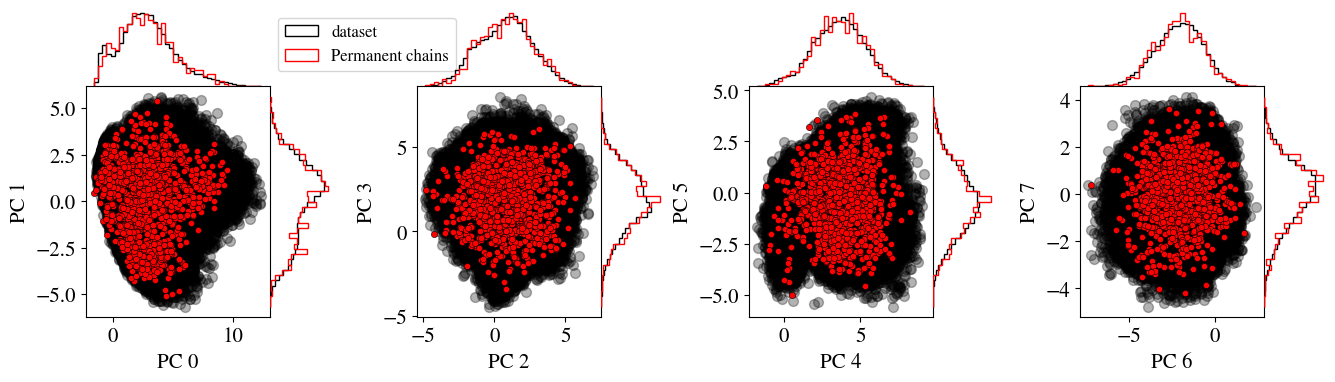

In [7]:
pc_proj = perm_chains["visible"] @ V_dataT.mT
pc_proj = pc_proj.cpu().numpy()


plot_mult_PCA(
    data_proj[:, :8],
    pc_proj[:, :8],
    labels=["dataset", "Permanent chains"],
)

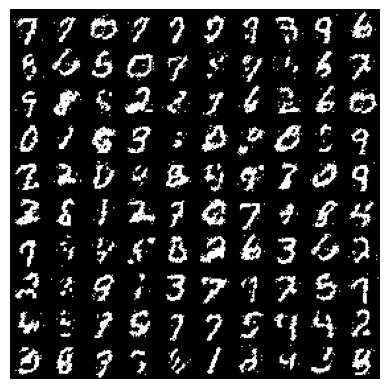

In [8]:
from rbms import plot_image
plot_image(
    perm_chains["visible"].cpu().numpy(),
    shape=(28, 28),
    grid_size=(10, 10),
    randomize=True,
)




# Sample the RBM


In [9]:
num_samples = 16 * 16
n_steps = 10000


samples = params.init_chains(num_samples=num_samples)
samples = params.sample_state(chains=samples, n_steps=n_steps)

samples_proj = samples["visible"] @ V_dataT.mT
samples_proj = samples_proj.cpu().numpy()


plot_mult_PCA(
    data_proj[:, :16],
    samples_proj[:, :16],
    labels=["dataset", "Permanent chains"],
)

KeyboardInterrupt: 

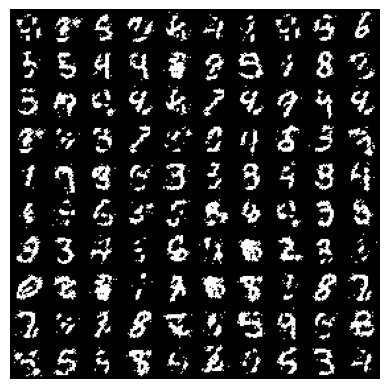

In [ ]:
from rbms import plot_image
plot_image(
    samples["visible"].cpu().numpy(),
    shape=(28, 28),
    grid_size=(10, 10),
    randomize=True,
)


In [ ]:
from rbms.utils import get_saved_updates

lup = get_saved_updates(filename)
print(lup)


[    1    51   101   151   201   251   301   351   401   451   501   551
   601   651   701   751   801   851   901   951  1001  1052  1102  1152
  1202  1252  1302  1352  1402  1452  1502  1552  1602  1652  1702  1752
  1802  1852  1902  1952  2002  2053  2103  2153  2203  2253  2303  2353
  2403  2453  2503  2553  2603  2653  2703  2753  2803  2853  2903  2953
  3003  3053  3104  3154  3204  3254  3304  3354  3404  3454  3504  3554
  3604  3654  3704  3754  3804  3854  3904  3954  4004  4054  4105  4155
  4205  4255  4305  4355  4405  4455  4505  4555  4605  4655  4705  4755
  4805  4855  4905  4955  5005  5055  5106  5156  5206  5256  5306  5356
  5406  5456  5506  5556  5606  5656  5706  5756  5806  5856  5906  5956
  6006  6056  6106  6157  6207  6257  6307  6357  6407  6457  6507  6557
  6607  6657  6707  6757  6807  6857  6907  6957  7007  7057  7107  7158
  7208  7258  7308  7358  7408  7458  7508  7558  7608  7658  7708  7758
  7808  7858  7908  7958  8008  8058  8108  8158  8

Text(0, 0.5, 'Singular vector value')

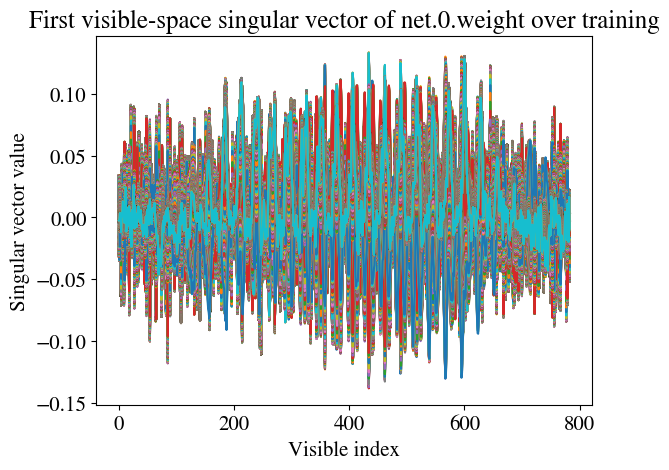

In [ ]:
all_u = []
all_s = []

for upd in lup:
    with h5py.File(filename, "r") as f:
        W0 = torch.tensor(
            f[f"update_{upd}"]["params"]["net.0.weight"][()],
            device=device,
            dtype=dtype,
        )

    # PyTorch Linear stores W as (hidden_dim, num_visibles).
    # Transpose so the left singular vectors live in visible/pixel space.
    W_visible = W0.T

    u, s, vh = torch.linalg.svd(W_visible, full_matrices=False)

    all_u.append(u.detach().cpu())
    all_s.append(s.detach().cpu())

    plt.plot(u[:, 0].detach().cpu())

plt.title("First visible-space singular vector of net.0.weight over training")
plt.xlabel("Visible index")
plt.ylabel("Singular vector value")


In [ ]:
# from rbms.io import load_params
# from rbms.partition_function.ais import compute_partition_function_ais
# all_LL = []
# # larr = [2,3,5,7,11,15,22,31,44,63,89,125,177,251,354,501,707]
# for upd in np.sort(lup):
#     params = load_params(filename, upd, device, dtype)
#     logZ = compute_partition_function_ais(1000,100,params)
#     LL_tr = compute_log_likelihood(train_dataset.data,torch.ones(train_dataset.data.shape[0]),params,logZ)
#     LL_te = compute_log_likelihood(test_dataset.data,torch.ones(test_dataset.data.shape[0]),params,logZ)
#     all_LL.append([LL_tr,LL_te])
#     print(upd,' ',LL_tr,' ',LL_te)

# Correlation

In [ ]:
from tqdm.auto import tqdm
import numpy as np
import torch
import matplotlib.pyplot as plt

NUM_CHAINS = 512
NUM_STEPS = 10000
DMALA_ALPHA = 0.5

torch.manual_seed(0)

num_visibles = train_dataset.data.shape[1]

initial_visible = torch.bernoulli(
    torch.full(
        (NUM_CHAINS, num_visibles),
        0.5,
        device=device,
        dtype=dtype,
    )
)

chains = params.init_chains(
    num_samples=NUM_CHAINS,
    start_v=initial_visible,
)

# Store spins on CPU as int8: -1 or +1.
# Memory in GB is approximately:
# (NUM_STEPS + 1) * NUM_CHAINS * num_visibles / 1e9
memory_gb = (NUM_STEPS + 1) * NUM_CHAINS * num_visibles / 1e9
print(f"Spin trajectory memory: {memory_gb:.2f} GB as int8")

spins = torch.empty(
    (NUM_STEPS + 1, NUM_CHAINS, num_visibles),
    dtype=torch.int8,
    device="cpu",
)

for step in tqdm(range(NUM_STEPS + 1)):
    visible_cpu = chains["visible"].detach().cpu()
    spins[step].copy_((2.0 * visible_cpu - 1.0).to(torch.int8))

    if step < NUM_STEPS:
        chains = params.sample_state(
            chains=chains,
            n_steps=1,
            kernel="dmala",
            kernel_params={"alpha": DMALA_ALPHA},
        )


Spin trajectory memory: 8.03 GB as int8


100%|██████████| 20001/20001 [03:55<00:00, 84.88it/s]


In [ ]:
def spin_autocorr_fft(
    spins,
    start=0,
    max_lag=5_000,
    component_batch=2_048,
    fft_device=None,
):
    """Compute normalized spin autocorrelation with FFT.

    spins has shape:
        time x chains x visibles

    The correlation is computed on the segment spins[start:].
    Each curve is normalized by its own tau=0 value.
    """

    if fft_device is None:
        fft_device = "cuda:0" if torch.cuda.is_available() else "cpu"

    segment = spins[start:]
    num_times, num_chains, num_visibles = segment.shape
    max_lag = min(max_lag, num_times - 1)

    # Mean spin per visible unit, averaged over time and chains in this segment.
    mean_spin = segment.to(torch.float32).mean(dim=(0, 1)).cpu()

    # Flatten chain and visible indices into components.
    flat = segment.reshape(num_times, num_chains * num_visibles)

    n_fft = 1 << (2 * num_times - 1).bit_length()

    counts = torch.arange(
        num_times,
        num_times - max_lag - 1,
        -1,
        device=fft_device,
        dtype=torch.float32,
    )

    numerator = torch.zeros(max_lag + 1, dtype=torch.float64)
    denominator = torch.tensor(0.0, dtype=torch.float64)

    num_components = flat.shape[1]

    for col_start in tqdm(range(0, num_components, component_batch), leave=False):
        col_stop = min(col_start + component_batch, num_components)

        block = flat[:, col_start:col_stop].to(
            device=fft_device,
            dtype=torch.float32,
        )

        # Column j corresponds to pixel index j % num_visibles.
        pixel_indices = torch.arange(
            col_start,
            col_stop,
            device="cpu",
        ) % num_visibles

        block = block - mean_spin[pixel_indices].to(fft_device).view(1, -1)

        block_fft = torch.fft.rfft(block, n=n_fft, dim=0)
        power = block_fft.abs().square()
        autocov = torch.fft.irfft(power, n=n_fft, dim=0)[: max_lag + 1]

        # Unbiased time-pair normalization: divide lag tau by T - tau.
        autocov = autocov / counts[:, None]

        numerator += autocov.sum(dim=1).detach().cpu().double()
        denominator += autocov[0].sum().detach().cpu().double()

    rho = numerator / denominator.clamp_min(1e-12)

    return rho.numpy()


STARTS = [1_000]
MAX_LAG = 5_000

curves = {}

from tqdm.auto import tqdm

for start in tqdm(STARTS, desc="Start points"):
    print(f"Computing autocorrelation from start={start}")
    curves[start] = spin_autocorr_fft(
        spins=spins,
        start=start,
        max_lag=MAX_LAG,
        component_batch=2_048,
        fft_device=device,
    )


Start points:   0%|          | 0/5 [00:00<?, ?it/s]

Computing autocorrelation from start=0


Start points:  20%|██        | 1/5 [11:31<46:05, 691.34s/it]

Computing autocorrelation from start=1000


Start points:  40%|████      | 2/5 [23:24<35:12, 704.07s/it]

...

ValueError: 
$\\rho(\\tau)$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x11edd63e0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$\\rho(\\tau)$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$\\rho(\\tau)$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1200x400 with 2 Axes>

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

FIT_MIN_RHO = 0.05
FIT_MAX_RHO = 0.8
fit_results = {}

for start, rho in curves.items():
    lags = np.arange(len(rho))
    rho_positive = np.clip(rho, 1e-12, None)

    fit_mask = (
        (lags > 0)
        & np.isfinite(rho)
        & (rho > FIT_MIN_RHO)
        & (rho < FIT_MAX_RHO)
    )

    axes[0].plot(lags, rho, label=f"start {start}")
    axes[1].plot(lags, rho_positive, label=f"start {start}")

    if fit_mask.sum() >= 2:
        slope, intercept = np.polyfit(lags[fit_mask], np.log(rho[fit_mask]), deg=1)
        tau_exp = -1.0 / slope if slope < 0 else np.inf
        fit_results[start] = tau_exp

        fit_lags = lags[fit_mask]
        fit_curve = np.exp(intercept + slope * fit_lags)

        axes[0].plot(fit_lags, fit_curve, "--", alpha=0.8)
        axes[1].plot(
            fit_lags,
            fit_curve,
            "--",
            alpha=0.8,
            label=f"fit start {start}, tau={tau_exp:.1f}",
        )
    else:
        fit_results[start] = np.nan

axes[0].set_title("Spin autocorrelation")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("rho")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Spin autocorrelation with exponential fits")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("rho")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

for start, tau_exp in fit_results.items():
    print(f"start {start}: exponential tau = {tau_exp:.2f} steps")


# Moment comparison

For each of the moment, we plot its estimation on the train set and on the currently considered dataset.

$m$ corresponds to the directing coefficient of a fitted line

$r$ corresponds to the pearson correlation coefficient between the two estimations


In [ ]:
corr_1b_train = train_dataset.data.mean(0).cpu().numpy()
corr_1b_test = test_dataset.data.mean(0).cpu().numpy()

corr_1b_pc = perm_chains["visible"].mean(0).cpu().numpy()
corr_1b_samples = samples["visible"].mean(0).cpu().numpy()

Text(0.5, 0.98, 'Frequencies')

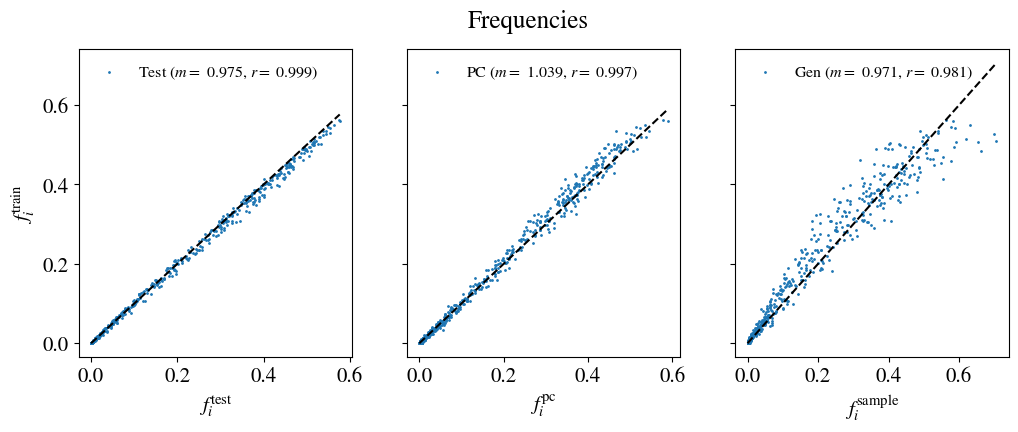

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
m1_test, r1_test, x, y, x_line = process_corr(corr_1b_test, corr_1b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m1_test:.3f}, $r=$ {r1_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$f_{i}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$f_{i}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m1_pc, r1_pc, x, y, x_line = process_corr(corr_1b_pc, corr_1b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m1_pc:.3f}, $r=$ {r1_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$f_{i}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m1_samples, r1_samples, x, y, x_line = process_corr(corr_1b_samples, corr_1b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m1_samples:.3f}, $r=$ {r1_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$f_{i}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle("Frequencies")

In [ ]:
corr_2b_train = (
    compute_2b_correlations(train_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
)
corr_2b_test = (
    compute_2b_correlations(test_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
)
corr_2b_pc = (
    compute_2b_correlations(
        perm_chains["visible"].cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
)
corr_2b_samples = (
    compute_2b_correlations(
        samples["visible"].data.cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
)

AssertionError: Torch not compiled with CUDA enabled

Text(0.5, 0.98, 'Covariances')

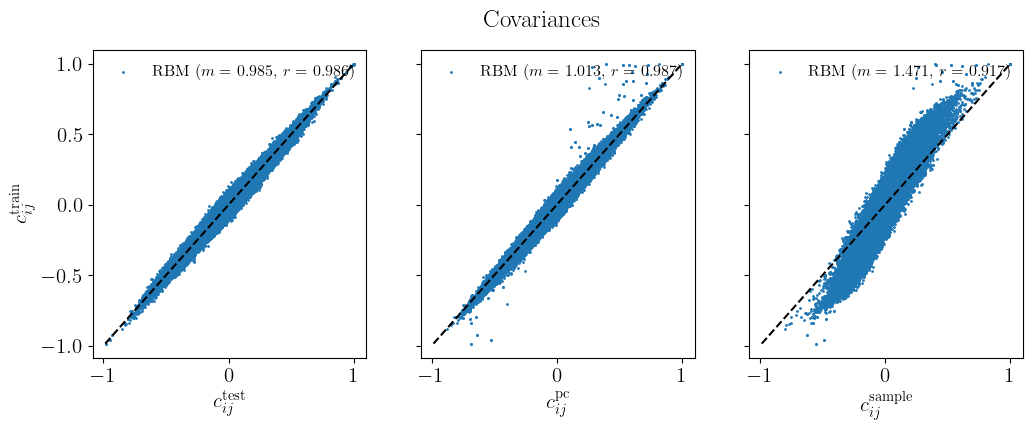

In [ ]:
threshold = 0.0

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

m2_test, r2_test, x, y, x_line = process_corr(corr_2b_test, corr_2b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m2_test:.3f}, $r=$ {r2_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$c_{ij}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$c_{ij}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m2_pc, r2_pc, x, y, x_line = process_corr(corr_2b_pc, corr_2b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m2_pc:.3f}, $r=$ {r2_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$c_{ij}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m2_samples, r2_samples, x, y, x_line = process_corr(corr_2b_samples, corr_2b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m2_samples:.3f}, $r=$ {r2_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$c_{ij}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle("Covariances")

In [ ]:
corr_3b_train = (
    compute_3b_correlations(train_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_test = (
    compute_3b_correlations(test_dataset.data.cuda(), batch_size=10, full_mat=False)
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_pc = (
    compute_3b_correlations(
        perm_chains["visible"].cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
    .flatten()
)
corr_3b_samples = (
    compute_3b_correlations(
        samples["visible"].data.cuda(), batch_size=10, full_mat=False
    )
    .cpu()
    .numpy()
    .flatten()
)

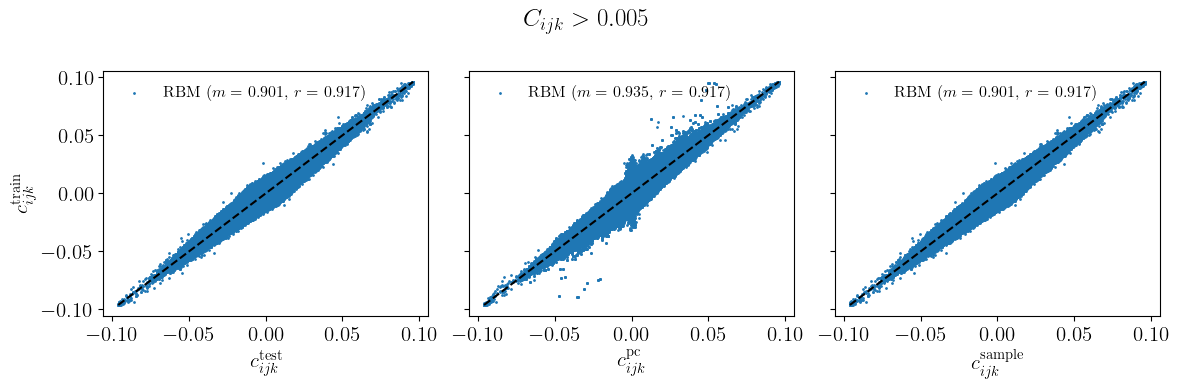

In [ ]:
# Terribly slow because of the number of points to plot

threshold = 0.005
mask = (np.abs(corr_3b_train) > threshold) | (np.abs(corr_3b_test) > threshold)

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
m3_test, r3_test, x, y, x_line = process_corr(corr_3b_test, corr_3b_train)
ax[0].scatter(
    x,
    y,
    s=1,
    label=f"Test ($m=$ {m3_test:.3f}, $r=$ {r3_test:.3f})",
)
ax[0].plot(x_line, x_line, "--", color="k")
ax[0].set_xlabel(r"$c_{ijk}^{\mathrm{test}}$")
ax[0].set_ylabel(r"$c_{ijk}^{\mathrm{train}}$")
ax[0].legend(loc="upper left", fontsize=11.5, frameon=False)

m3_pc, r3_pc, x, y, x_line = process_corr(corr_3b_pc, corr_3b_train)
ax[1].scatter(
    x,
    y,
    s=1,
    label=f"PC ($m=$ {m3_pc:.3f}, $r=$ {r3_pc:.3f})",
)
ax[1].plot(x_line, x_line, "--", color="k")
ax[1].set_xlabel(r"$c_{ijk}^{\mathrm{pc}}$")
ax[1].legend(loc="upper left", fontsize=11.5, frameon=False)

m3_samples, r3_samples, x, y, x_line = process_corr(corr_3b_samples, corr_3b_train)
ax[2].scatter(
    x,
    y,
    s=1,
    label=f"Gen ($m=$ {m3_samples:.3f}, $r=$ {r3_samples:.3f})",
)
ax[2].plot(x_line, x_line, "--", color="k")
ax[2].set_xlabel(r"$c_{ijk}^{\mathrm{sample}}$")
ax[2].legend(loc="upper left", fontsize=11.5, frameon=False)

fig.suptitle(r"$C_{ijk} > 0.005$")
fig.tight_layout()

# Plot images

If your dataset is an image dataset, you can plot images and generated data here


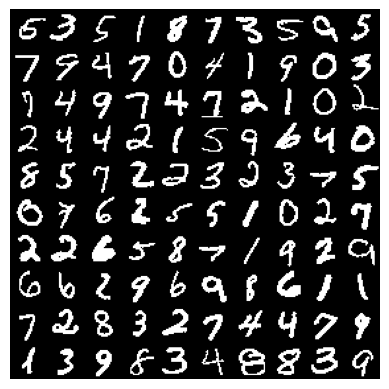

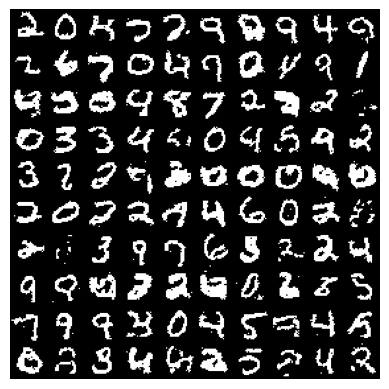

In [ ]:
img_shape = (28, 28)
grid_size = (10, 10)
randomize = True


plot_image(
    train_dataset.data.cpu().numpy(),
    shape=img_shape,
    grid_size=grid_size,
    randomize=randomize,
)

plot_image(
    samples["visible"].cpu().numpy(),
    shape=img_shape,
    grid_size=grid_size,
    randomize=randomize,
)

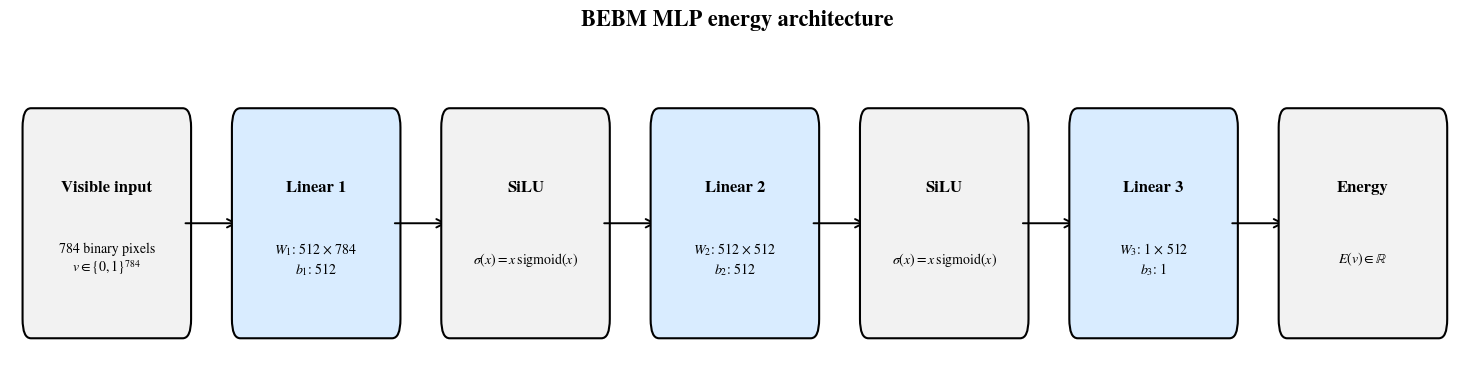

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

layers = [
    ("Visible input", "784 binary pixels\n$v \\in \\{0,1\\}^{784}$"),
    ("Linear 1", "$W_1$: 512 × 784\n$b_1$: 512"),
    ("SiLU", "$\\sigma(x)=x\\,\\mathrm{sigmoid}(x)$"),
    ("Linear 2", "$W_2$: 512 × 512\n$b_2$: 512"),
    ("SiLU", "$\\sigma(x)=x\\,\\mathrm{sigmoid}(x)$"),
    ("Linear 3", "$W_3$: 1 × 512\n$b_3$: 1"),
    ("Energy", "$E(v) \\in \\mathbb{R}$"),
]

fig, ax = plt.subplots(figsize=(15, 4))
ax.axis("off")

x_positions = range(len(layers))
y = 0.5

for i, (title, text) in enumerate(layers):
    box = FancyBboxPatch(
        (i * 2.0, y),
        1.45,
        0.8,
        boxstyle="round,pad=0.08",
        linewidth=1.5,
        edgecolor="black",
        facecolor="#f2f2f2" if "Linear" not in title else "#d9ecff",
    )
    ax.add_patch(box)

    ax.text(
        i * 2.0 + 0.725,
        y + 0.55,
        title,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )

    ax.text(
        i * 2.0 + 0.725,
        y + 0.25,
        text,
        ha="center",
        va="center",
        fontsize=10,
    )

    if i < len(layers) - 1:
        arrow = FancyArrowPatch(
            (i * 2.0 + 1.45, y + 0.4),
            ((i + 1) * 2.0, y + 0.4),
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.4,
            color="black",
        )
        ax.add_patch(arrow)

ax.set_xlim(-0.2, len(layers) * 2.0 - 0.3)
ax.set_ylim(0.25, 1.55)

fig.suptitle(
    "BEBM MLP energy architecture",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()
plt.show()
